## Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load dataset
df = pd.read_excel('/content/cirrhosis_dataset.xlsx')

#inspect the data
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400.0,D,D-penicillamine,21464.0,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500.0,C,D-penicillamine,20617.0,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012.0,D,D-penicillamine,25594.0,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925.0,D,D-penicillamine,19994.0,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504.0,CL,Placebo,13918.0,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


## Data Structure

In [ ]:
df.shape

(620, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             620 non-null    int64  
 1   N_Days         620 non-null    float64
 2   Status         620 non-null    object 
 3   Drug           514 non-null    object 
 4   Age            620 non-null    float64
 5   Sex            620 non-null    object 
 6   Ascites        514 non-null    object 
 7   Hepatomegaly   514 non-null    object 
 8   Spiders        514 non-null    object 
 9   Edema          620 non-null    object 
 10  Bilirubin      620 non-null    float64
 11  Cholesterol    486 non-null    float64
 12  Albumin        620 non-null    float64
 13  Copper         512 non-null    float64
 14  Alk_Phos       514 non-null    float64
 15  SGOT           514 non-null    float64
 16  Tryglicerides  484 non-null    float64
 17  Platelets      609 non-null    float64
 18  Prothrombi

In [ ]:
#Check the total for duplicated data
df.duplicated().sum()

np.int64(2)

In [ ]:
#Check for missing values per column
df.isna().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [ ]:
#Drop irrelevant columns
df = df.drop(columns=["ID", "N_Days", "Status", "Drug", "Cholesterol", "Tryglicerides"])

In [ ]:
df.shape

(620, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           620 non-null    float64
 1   Sex           620 non-null    object 
 2   Ascites       514 non-null    object 
 3   Hepatomegaly  514 non-null    object 
 4   Spiders       514 non-null    object 
 5   Edema         620 non-null    object 
 6   Bilirubin     620 non-null    float64
 7   Albumin       620 non-null    float64
 8   Copper        512 non-null    float64
 9   Alk_Phos      514 non-null    float64
 10  SGOT          514 non-null    float64
 11  Platelets     609 non-null    float64
 12  Prothrombin   618 non-null    float64
 13  Stage         614 non-null    float64
dtypes: float64(9), object(5)
memory usage: 67.9+ KB


## DROP DUPLICATES

In [ ]:
df = df.drop_duplicates()

## Check Target Column

In [ ]:
#Check Stage (target column)
df['Stage'].unique()

array([ 4.,  3.,  2.,  1., nan])

In [ ]:
df = df.dropna(subset=["Stage"])
df["Stage"] = df["Stage"].astype(int)

#Check
print(df['Stage'].value_counts())

Stage
3    311
4    183
2     97
1     21
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 0 to 619
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           612 non-null    float64
 1   Sex           612 non-null    object 
 2   Ascites       512 non-null    object 
 3   Hepatomegaly  512 non-null    object 
 4   Spiders       512 non-null    object 
 5   Edema         612 non-null    object 
 6   Bilirubin     612 non-null    float64
 7   Albumin       612 non-null    float64
 8   Copper        510 non-null    float64
 9   Alk_Phos      512 non-null    float64
 10  SGOT          512 non-null    float64
 11  Platelets     601 non-null    float64
 12  Prothrombin   610 non-null    float64
 13  Stage         612 non-null    int64  
dtypes: float64(8), int64(1), object(5)
memory usage: 71.7+ KB


### Data Splitting


In [ ]:
#Select Features (X) and Target (y)
input = df.drop('Stage', axis = 1)
output = df['Stage']

#Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size=0.3, random_state=0)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)

x_train:  (428, 13)
x_test:  (184, 13)


## Tidying Up The Dataframe

In [ ]:
#Check duplicate
print("x_train duplicate: ", x_train.duplicated().sum())
print("x_test duplicate: ", x_test.duplicated().sum())

x_train duplicate:  0
x_test duplicate:  0


In [ ]:
#Check gender data
print('x_train data:', x_train['Sex'].unique())
print('x_test data:', x_test['Sex'].unique())

x_train data: ['F' 'Male' 'M' 'Female' 'Male ']
x_test data: ['M' 'F' 'Female' 'Male']


In [ ]:
#Check ascites data
print('x_train data:', x_train['Ascites'].unique())
print('x_test data:', x_test['Ascites'].unique())

x_train data: [nan 'N' 'Y' 'Yes' 'No']
x_test data: ['N' nan 'Y' 'No']


In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 428 entries, 357 to 567
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           428 non-null    float64
 1   Sex           428 non-null    object 
 2   Ascites       359 non-null    object 
 3   Hepatomegaly  359 non-null    object 
 4   Spiders       359 non-null    object 
 5   Edema         428 non-null    object 
 6   Bilirubin     428 non-null    float64
 7   Albumin       428 non-null    float64
 8   Copper        357 non-null    float64
 9   Alk_Phos      359 non-null    float64
 10  SGOT          359 non-null    float64
 11  Platelets     419 non-null    float64
 12  Prothrombin   426 non-null    float64
dtypes: float64(8), object(5)
memory usage: 46.8+ KB


In [ ]:
x_train.isna().sum()

,0
Age,0
Sex,0
Ascites,69
Hepatomegaly,69
Spiders,69
Edema,0
Bilirubin,0
Albumin,0
Copper,71
Alk_Phos,69


In [ ]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 587 to 134
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           184 non-null    float64
 1   Sex           184 non-null    object 
 2   Ascites       153 non-null    object 
 3   Hepatomegaly  153 non-null    object 
 4   Spiders       153 non-null    object 
 5   Edema         184 non-null    object 
 6   Bilirubin     184 non-null    float64
 7   Albumin       184 non-null    float64
 8   Copper        153 non-null    float64
 9   Alk_Phos      153 non-null    float64
 10  SGOT          153 non-null    float64
 11  Platelets     182 non-null    float64
 12  Prothrombin   184 non-null    float64
dtypes: float64(8), object(5)
memory usage: 20.1+ KB


In [ ]:
x_test.isna().sum()

,0
Age,0
Sex,0
Ascites,31
Hepatomegaly,31
Spiders,31
Edema,0
Bilirubin,0
Albumin,0
Copper,31
Alk_Phos,31


## Change "Age" from Days -> Years

In [ ]:
x_train["Age"] = x_train["Age"].astype(int)
x_test["Age"] = x_test["Age"].astype(int)

In [ ]:
#change age from days to year
x_train["Age"] = (x_train["Age"] / 365).round()
x_test["Age"] = (x_test["Age"] / 365).round()

print(x_train['Age'])

357    58.0
599    50.0
369    42.0
187    36.0
509    50.0
       ... 
278    33.0
9      71.0
366    61.0
193    57.0
567    53.0
Name: Age, Length: 428, dtype: float64


## Handle Inconsistent Values

In [ ]:
x_train['Sex'] = x_train['Sex'].replace("Male", "M")
x_test['Sex'] = x_test['Sex'].replace("Male", "M")

x_train['Sex'] = x_train['Sex'].replace("Male ", "M")
x_test['Sex'] = x_test['Sex'].replace("Male ", "M")

x_train['Sex'] = x_train['Sex'].replace("Female", "F")
x_test['Sex'] = x_test['Sex'].replace("Female", "F")

#Check
print(x_train['Sex'].value_counts(), "\n")
print(x_test['Sex'].value_counts())

Sex
F    383
M     45
Name: count, dtype: int64 

Sex
F    175
M      9
Name: count, dtype: int64


In [ ]:
x_train['Ascites'] = x_train['Ascites'].replace("Yes", "Y")
x_test['Ascites'] = x_test['Ascites'].replace("Yes", "Y")

x_train['Ascites'] = x_train['Ascites'].replace("No", "N")
x_test['Ascites'] = x_test['Ascites'].replace("No", "N")

#Check
print(x_train['Ascites'].value_counts(), "\n")
print(x_test['Ascites'].value_counts())

Ascites
N    323
Y     36
Name: count, dtype: int64 

Ascites
N    138
Y     15
Name: count, dtype: int64


In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 428 entries, 357 to 567
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           428 non-null    float64
 1   Sex           428 non-null    object 
 2   Ascites       359 non-null    object 
 3   Hepatomegaly  359 non-null    object 
 4   Spiders       359 non-null    object 
 5   Edema         428 non-null    object 
 6   Bilirubin     428 non-null    float64
 7   Albumin       428 non-null    float64
 8   Copper        357 non-null    float64
 9   Alk_Phos      359 non-null    float64
 10  SGOT          359 non-null    float64
 11  Platelets     419 non-null    float64
 12  Prothrombin   426 non-null    float64
dtypes: float64(8), object(5)
memory usage: 46.8+ KB


## Data Cleaning (Missing Values)

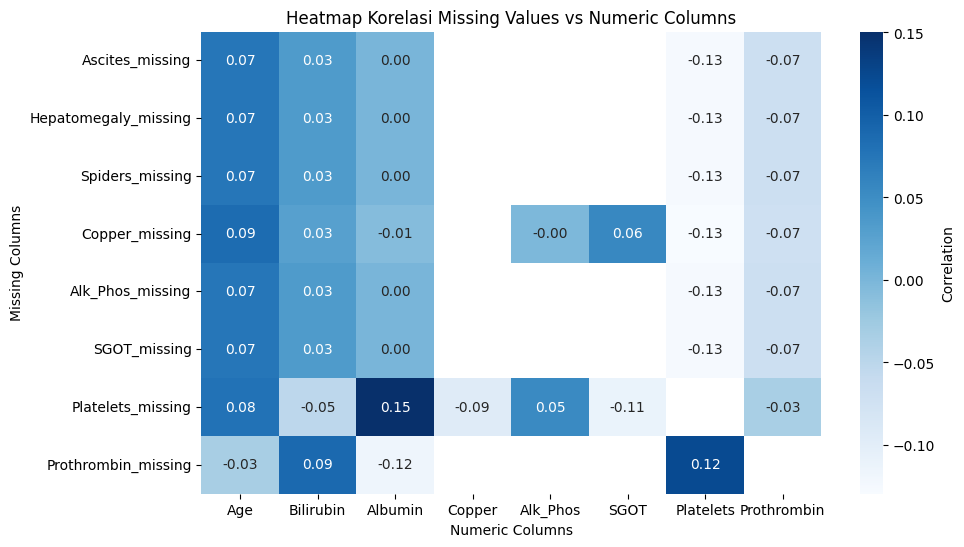

In [ ]:
import seaborn as sns

df_train = x_train.copy()
df_test = x_test.copy()

missing_cols = ["Ascites", "Hepatomegaly", "Spiders", "Copper", "Alk_Phos", "SGOT", "Platelets", "Prothrombin"]

for col in missing_cols:
    df_train[col + "_missing"] = df_train[col].isna().astype(int)
    df_test[col + "_missing"] = df_test[col].isna().astype(int)

numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if not col.endswith("_missing")]

missing_indicators = [col + "_missing" for col in missing_cols]
corr_matrix = df_train[missing_indicators + numeric_cols].corr().loc[missing_indicators, numeric_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", cbar_kws={'label': 'Correlation'})
plt.title("Heatmap Korelasi Missing Values vs Numeric Columns")
plt.ylabel("Missing Columns")
plt.xlabel("Numeric Columns")
plt.show()

### 1) Numerical Column

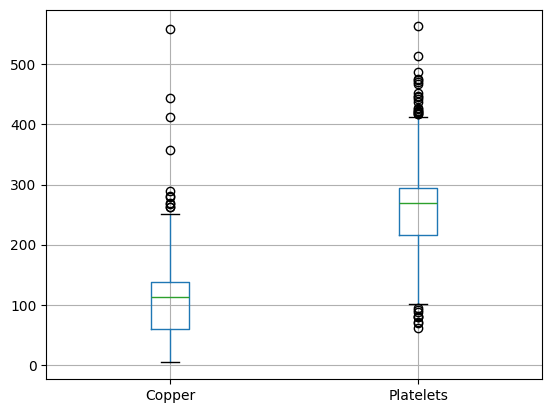

In [ ]:
bp = x_train.boxplot(column=['Copper', 'Platelets'])
plt.show()

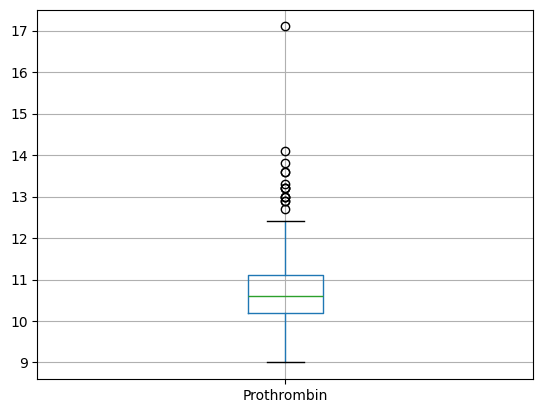

In [ ]:
bp2 = x_train.boxplot('Prothrombin')
plt.show()

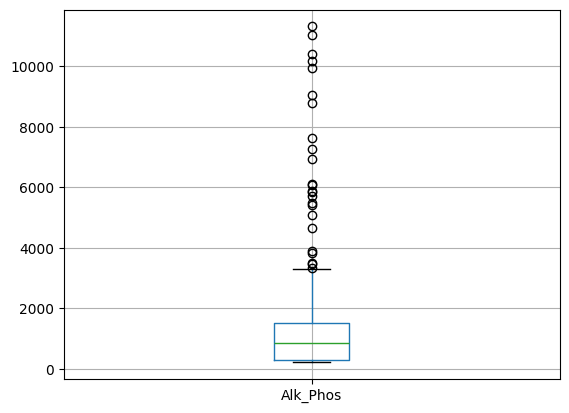

In [ ]:
bp3 = x_train.boxplot('Alk_Phos')
plt.show()

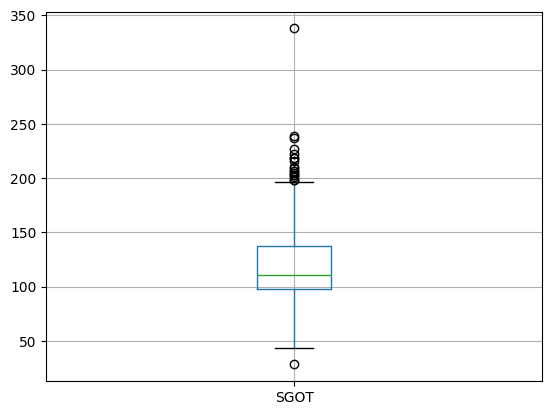

In [ ]:
bp4 = x_train.boxplot('SGOT')
plt.show()

In [ ]:
x_train['Copper'].fillna(x_train['Copper'].median(), inplace=True)
x_test['Copper'].fillna(x_train['Copper'].median(), inplace=True)

In [ ]:
x_train['Platelets'].fillna(x_train['Platelets'].median(), inplace=True)
x_test['Platelets'].fillna(x_train['Platelets'].median(), inplace=True)

In [ ]:
x_train['Prothrombin'].fillna(x_train['Prothrombin'].median(), inplace=True)
x_test['Prothrombin'].fillna(x_train['Prothrombin'].median(), inplace=True)

In [ ]:
x_train['Alk_Phos'].fillna(x_train['Alk_Phos'].median(), inplace=True)
x_test['Alk_Phos'].fillna(x_train['Alk_Phos'].median(), inplace=True)

In [ ]:
x_train['SGOT'].fillna(x_train['SGOT'].median(), inplace=True)
x_test['SGOT'].fillna(x_train['SGOT'].median(), inplace=True)

### 2) Categorical Column

In [ ]:
x_train["Ascites"] = x_train["Ascites"].fillna(x_train["Ascites"].mode()[0])
x_test["Ascites"] = x_test["Ascites"].fillna(x_train["Ascites"].mode()[0])

x_train["Hepatomegaly"] = x_train["Hepatomegaly"].fillna(x_train["Hepatomegaly"].mode()[0])
x_test["Hepatomegaly"] = x_test["Hepatomegaly"].fillna(x_train["Hepatomegaly"].mode()[0])

x_train["Spiders"] = x_train["Spiders"].fillna(x_train["Spiders"].mode()[0])
x_test["Spiders"] = x_test["Spiders"].fillna(x_train["Spiders"].mode()[0])

In [ ]:
x_train.isna().sum()

,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0
Albumin,0
Copper,0
Alk_Phos,0


## Handle Outliers

In [ ]:
x_train['Bilirubin'] = np.log1p(x_train['Bilirubin'])
x_test['Bilirubin'] = np.log1p(x_test['Bilirubin'])

In [ ]:
x_train['SGOT'] = np.log1p(x_train['SGOT'])
x_test['SGOT'] = np.log1p(x_test['SGOT'])

In [ ]:
x_train['Platelets'] = np.log1p(x_train['Platelets'])
x_test['Platelets'] = np.log1p(x_test['Platelets'])

## ENCODING

In [ ]:
x_train.head()

,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Albumin,Copper,Alk_Phos,SGOT,Platelets,Prothrombin
357,58.0,F,N,N,N,N,1.386294,3.46,113.0,860.0,4.715817,4.700480,10.4
599,50.0,F,N,N,N,N,0.530628,3.90,115.0,232.0,4.635699,5.587249,10.3
369,42.0,F,N,N,N,N,1.686399,4.52,113.0,860.0,4.715817,4.634729,10.8
187,36.0,F,N,Y,N,N,2.708050,3.43,251.0,2870.0,5.039870,5.594711,11.5
509,50.0,F,N,N,N,N,0.530628,3.90,114.0,230.0,4.632785,5.587249,10.3


In [ ]:
#binary encoding
binary_encode = {'Sex':{'M': 1, 'F': 0},
                 'Ascites':{'Y': 1, 'N': 0},
                 'Hepatomegaly':{'Y': 1, 'N': 0},
                 'Spiders':{'Y': 1, 'N': 0}
                 }
x_train = x_train.replace(binary_encode)
x_test = x_test.replace(binary_encode)

In [ ]:
#label encoding (ordinal)
from sklearn.preprocessing import LabelEncoder

label_encode = LabelEncoder()

x_train["Edema"] = label_encode.fit_transform(x_train["Edema"])
x_test["Edema"] = label_encode.fit_transform(x_test["Edema"])

In [ ]:
x_train.head()

,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Albumin,Copper,Alk_Phos,SGOT,Platelets,Prothrombin
357,58.0,0,0,0,0,0,1.386294,3.46,113.0,860.0,4.715817,4.700480,10.4
599,50.0,0,0,0,0,0,0.530628,3.90,115.0,232.0,4.635699,5.587249,10.3
369,42.0,0,0,0,0,0,1.686399,4.52,113.0,860.0,4.715817,4.634729,10.8
187,36.0,0,0,1,0,0,2.708050,3.43,251.0,2870.0,5.039870,5.594711,11.5
509,50.0,0,0,0,0,0,0.530628,3.90,114.0,230.0,4.632785,5.587249,10.3


# SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(
    sampling_strategy={
        1: 100,
        2: 120
    },
    random_state=42,
    k_neighbors=3
)

x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_sm).value_counts())

Before:
Stage
3    215
4    130
2     66
1     17
Name: count, dtype: int64

After:
Stage
2    220
3    215
1    200
4    130
Name: count, dtype: int64


##SCALING

In [ ]:
# use robust scaler for 'Copper'
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train['Copper'] = scaler.fit_transform(x_train[['Copper']])
x_test['Copper'] = scaler.transform(x_test[['Copper']])

In [ ]:
# use robust scaler for 'SGOT'
from sklearn.preprocessing import RobustScaler

scaler2 = RobustScaler()

x_train['SGOT'] = scaler2.fit_transform(x_train[['SGOT']])
x_test['SGOT'] = scaler2.transform(x_test[['SGOT']])

In [ ]:
# use robust scaler for 'Platelets'
scaler3 = RobustScaler()

x_train['Platelets'] = scaler3.fit_transform(x_train[['Platelets']])
x_test['Platelets'] = scaler3.transform(x_test[['Platelets']])

In [ ]:
# use robust scaler for 'Platelets'
scaler4 = RobustScaler()

x_train['Bilirubin'] = scaler4.fit_transform(x_train[['Bilirubin']])
x_test['Bilirubin'] = scaler4.transform(x_test[['Bilirubin']])

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression multiclass
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
logreg.fit(x_train, y_train)

y_pred = logreg.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.625
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.46      0.19      0.27        31
           3       0.66      0.81      0.73        96
           4       0.61      0.58      0.60        53

    accuracy                           0.62       184
   macro avg       0.43      0.40      0.40       184
weighted avg       0.59      0.62      0.60       184



## Random Forest Modelling

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6304347826086957
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.33      0.23      0.27        31
           3       0.70      0.76      0.73        96
           4       0.62      0.68      0.65        53

    accuracy                           0.63       184
   macro avg       0.41      0.42      0.41       184
weighted avg       0.60      0.63      0.61       184



## XGBOOSTING

In [ ]:
y_train_enc = y_train - 1
y_test_enc = y_test - 1

from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(x_train, y_train_enc)
y_pred_enc = model.predict(x_test)

y_pred = y_pred_enc + 1

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6413043478260869
              precision    recall  f1-score   support

           1       0.20      0.25      0.22         4
           2       0.30      0.19      0.24        31
           3       0.73      0.77      0.75        96
           4       0.64      0.70      0.67        53

    accuracy                           0.64       184
   macro avg       0.47      0.48      0.47       184
weighted avg       0.62      0.64      0.63       184



In [ ]:
!pip install catboost

## Cat Boosting

In [ ]:
from catboost import CatBoostClassifier

classes = y_train.unique()
counts = y_train.value_counts()
total = len(y_train)
class_weights = {c: total/(len(classes)*counts[c]) for c in classes}

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    class_weights=class_weights,
    random_state=42,
    verbose=50
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0:	learn: 1.3284408	total: 7.51ms	remaining: 3.75s
50:	learn: 0.6248373	total: 202ms	remaining: 1.78s
100:	learn: 0.4019499	total: 406ms	remaining: 1.6s
150:	learn: 0.2900649	total: 610ms	remaining: 1.41s
200:	learn: 0.2245967	total: 956ms	remaining: 1.42s
250:	learn: 0.1812188	total: 1.4s	remaining: 1.38s
300:	learn: 0.1499371	total: 1.83s	remaining: 1.21s
350:	learn: 0.1277116	total: 2.31s	remaining: 982ms
400:	learn: 0.1106532	total: 2.78s	remaining: 686ms
450:	learn: 0.0958470	total: 3.16s	remaining: 344ms
499:	learn: 0.0842947	total: 3.5s	remaining: 0us
Accuracy: 0.625
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           2       0.28      0.23      0.25        31
           3       0.76      0.71      0.74        96
           4       0.62      0.75      0.68        53

    accuracy                           0.62       184
   macro avg       0.42      0.42      0.42       184
weighted avg       0.63      0.62      

## LightGBM

In [ ]:
from lightgbm import LGBMClassifier

classes = y_train.unique()
counts = y_train.value_counts()
total = len(y_train)

model = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6521739130434783
              precision    recall  f1-score   support

           1       0.20      0.25      0.22         4
           2       0.33      0.26      0.29        31
           3       0.76      0.75      0.75        96
           4       0.65      0.74      0.69        53

    accuracy                           0.65       184
   macro avg       0.49      0.50      0.49       184
weighted avg       0.64      0.65      0.65       184



## Hyperparameter Tuning

### LightGBM

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 8],
    'num_leaves': [15, 63],
    'min_child_samples': [20],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0],
    'reg_lambda': [0]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 15, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}
Accuracy: 0.6304347826086957
              precision    recall  f1-score   support

           1       0.14      0.25      0.18         4
           2       0.27      0.19      0.23        31
           3       0.73      0.74      0.74        96
           4       0.66      0.72      0.68        53

    accuracy                           0.63       184
   macro avg       0.45      0.48      0.46       184
weighted avg       0.62      0.63      0.62       184



### XG Boosting

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.2],
    'reg_alpha': [0],
    'reg_lambda': [1]
}

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train_enc)
best_model = grid.best_estimator_

y_pred_enc = best_model.predict(x_test)
y_pred = y_pred_enc + 1

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Accuracy: 0.6195652173913043
              precision    recall  f1-score   support

           1       0.50      0.25      0.33         4
           2       0.32      0.23      0.26        31
           3       0.68      0.73      0.70        96
           4       0.63      0.68      0.65        53

    accuracy                           0.62       184
   macro avg       0.53      0.47      0.49       184
weighted avg       0.60      0.62      0.61       184



## Threshold Tuning

LIGHT GBM

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

y_prob = model.predict_proba(x_test)

def tune_threshold(y_true, y_prob, thresholds=np.arange(0.05, 0.6, 0.05)):
    n_classes = y_prob.shape[1]
    best_thresholds = np.zeros(n_classes)

    for class_idx in range(n_classes):
        best_f1 = 0
        best_t = 0
        for t in thresholds:
            y_pred = np.argmax(y_prob, axis=1)
            y_pred[y_prob[:, class_idx] > t] = class_idx
            f1 = f1_score(y_true - 1, y_pred, average='macro')
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds[class_idx] = best_t
        print(f"Class {class_idx + 1} optimal threshold: {best_t}, F1: {best_f1:.4f}")

    return best_thresholds

optimal_thresholds = tune_threshold(y_test, y_prob)

y_pred = np.argmax(y_prob, axis=1)
for i, t in enumerate(optimal_thresholds):
    y_pred[y_prob[:, i] > t] = i
y_pred = y_pred + 1

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Class 1 optimal threshold: 0.05, F1: 0.4981
Class 2 optimal threshold: 0.25, F1: 0.5042
Class 3 optimal threshold: 0.5, F1: 0.4893
Class 4 optimal threshold: 0.15000000000000002, F1: 0.4934
Accuracy: 0.657608695652174
              precision    recall  f1-score   support

           1       0.25      0.25      0.25         4
           2       0.32      0.23      0.26        31
           3       0.80      0.73      0.77        96
           4       0.61      0.81      0.69        53

    accuracy                           0.66       184
   macro avg       0.49      0.50      0.49       184
weighted avg       0.65      0.66      0.65       184



### XG Boosting

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

xgb_model_prob = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model_prob.fit(x_train, y_train_enc)

y_proba = xgb_model_prob.predict_proba(x_test)

best_thresholds = []
for i in range(4):
    best_f1 = 0
    best_t = 0.5
    for t in np.arange(0.2, 0.81, 0.05):
        y_pred_temp = (y_proba[:, i] >= t).astype(int)
        f1 = f1_score((y_test_enc == i).astype(int), y_pred_temp)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)

print("Best thresholds per class:", best_thresholds)

y_pred_thresh = np.argmax(y_proba / best_thresholds, axis=1)
y_pred_final = y_pred_thresh + 1

print("Accuracy (threshold tuned):", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Best thresholds per class: [np.float64(0.5499999999999999), np.float64(0.2), np.float64(0.39999999999999997), np.float64(0.44999999999999996)]
Accuracy (threshold tuned): 0.625
              precision    recall  f1-score   support

           1       0.20      0.25      0.22         4
           2       0.29      0.26      0.27        31
           3       0.73      0.72      0.73        96
           4       0.65      0.70      0.67        53

    accuracy                           0.62       184
   macro avg       0.47      0.48      0.47       184
weighted avg       0.62      0.62      0.62       184

